# Phase 1 — SWIFT Address Town/Country Extraction

This notebook **orchestrates and demonstrates** the pipeline. All business logic lives in
`src/swift_address/`, so Phase 2 can import the same modules without lifting code out of a notebook.

What the run does, in order:

1. load and validate the runtime config and the external group config;
2. **Pass 1** — build one combined address per row per group, clean it deterministically, and
   finalize every empty group instance as `NO_TOWN` / `NO_COUNTRY` **without calling Gemini**;
3. deduplicate the non-empty cleaned addresses across every row *and* every group;
4. **Pass 2** — extract each unique cache miss exactly once, with structured JSON output;
5. verify the evidence in Python, cross-check the predicted town against the Town/Country
   reference, select the policy scenario, apply the configured reliability weights, and compute
   the Composite Weighted Score;
6. write the expanded CSV, the error sidecar, and run metrics;
7. build the executive report — KPIs, score distribution, scenario mix, and HITL threshold
   sensitivity.

> **Credentials.** Nothing in this notebook prints or stores a secret. If no Gemini credentials are
> present in the environment the run falls back to an offline dry-run stub, which is clearly labelled
> in its own output and in the run metrics.

## 1 — Imports and configuration paths

In [1]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path

import pandas as pd

# The package lives in src/; add it to the path so the notebook can be run in place.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from swift_address import io as swift_io
from swift_address.cache import AddressCache
from swift_address.gemini_client import GeminiClient, MockExtractionClient
from swift_address.grouping import load_group_config
from swift_address.pipeline import Phase1Pipeline
from swift_address.reference_data import (
    TownCountryReferenceError,
    build_provider,
    build_town_country_provider,
    find_iso_provider,
)
from swift_address import reporting
from swift_address.schemas import load_prompt_contract
from swift_address.settings import (
    credentials_available,
    dry_run_requested,
    load_config,
    resolve_model_name,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)-7s %(name)s: %(message)s",
    stream=sys.stdout,
    force=True,
)

CONFIG_PATH = REPO_ROOT / "config" / "config.yaml"
INPUT_PATH = REPO_ROOT / "data" / "sample_input.csv"

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

print("repo root :", REPO_ROOT)
print("config    :", CONFIG_PATH.relative_to(REPO_ROOT))
print("input     :", INPUT_PATH.relative_to(REPO_ROOT))

repo root : /home/user/swift_tc
config    : config/config.yaml
input     : data/sample_input.csv


## 2 — Load and validate configuration

`load_config` validates the whole file up front: naming templates must cover all 11 output fields,
every reliability-weight scenario required by `SCORING_SPEC.md` must be present, and weights must lie
in `[0, 1]`. The group config is validated separately for unique IDs and no duplicate source fields
within a group.

In [2]:
config = load_config(CONFIG_PATH, base_dir=REPO_ROOT)
group_config = load_group_config(config.path(config.project.group_config_path))
prompt = load_prompt_contract(
    config.path(config.project.prompt_path), config.project.prompt_version
)

print(f"prompt version   : {config.project.prompt_version}")
print(f"prompt source    : {prompt.source_path.name}  ({len(prompt.text)} chars)")
print(f"naming style     : {config.output.naming_style}")
print(f"fields per group : {config.fields_per_group}")
print(f"HITL threshold   : {config.scoring.hitl_threshold}")
print()

print("Reliability weights (loaded from YAML — no magic numbers in Python):")
display(
    pd.DataFrame(
        [
            {"scenario": name, "town_weight": w.town_weight, "country_weight": w.country_weight}
            for name, w in config.scoring.rules.items()
        ]
    )
)

prompt version   : v2-composite-weighted
prompt source    : GEMINI_EXTRACTION_PROMPT.md  (5333 chars)
naming style     : canonical
fields per group : 12
HITL threshold   : 0.8

Reliability weights (loaded from YAML — no magic numbers in Python):


,scenario,town_weight,country_weight
0,both_explicit,1.00,1.0
1,country_explicit_town_inferred,0.50,1.0
2,town_explicit_country_inferred,0.75,0.5
3,town_explicit_country_ambiguous,0.50,0.0
4,neither_explicit_both_inferred,0.20,0.2
5,no_defensible_prediction,0.00,0.0
6,town_inferred_country_ambiguous,0.20,0.0


In [3]:
groups = group_config.enabled_groups
print(f"groups configured : {len(group_config.groups)}")
print(f"groups enabled    : {len(groups)}")
print(f"lines per group   : {sorted({g.line_count for g in groups})}")
print()

display(
    pd.DataFrame(
        [
            {"group_id": g.group_id, "lines": g.line_count,
             "source_fields": ", ".join(g.source_fields)}
            for g in groups
        ]
    ).head(20)
)

print("\nThe 11 output columns generated for group 15:")
for name in config.group_column_names("15"):
    print("  -", name)

groups configured : 16
groups enabled    : 16
lines per group   : [3]



,group_id,lines,source_fields
0,1,3,"INT_PAY_AGT_ADDR_1, INT_PAY_AGT_ADDR_2, INT_PAY_AGT_ADDR_3"
1,2,3,"INT_PAY_AGT_AGT_ADDR_1, INT_PAY_AGT_AGT_ADDR_2, INT_PAY_..."
2,3,3,"INT_PAY_BNF_ADDR_LINE_1, INT_PAY_BNF_ADDR_LINE_2, INT_PA..."
3,4,3,"INT_PAY_ORDR_ADDR_LINE_1, INT_PAY_ORDR_ADDR_LINE_2, INT_..."
4,5,3,"INT_RCV_AGT_AGT_ADDR_1, INT_RCV_AGT_AGT_ADDR_2, INT_RCV_..."
5,6,3,"INT_RCV_DEBTOR_ADDR_1, INT_RCV_DEBTOR_ADDR_2, INT_RCV_DE..."
6,7,3,"INT_RCV_PAY_AGT_ADDR_1, INT_RCV_PAY_AGT_ADDR_2, INT_RCV_..."
7,8,3,"INT_SNDR_CORR_ADDR_LINE_1, INT_SNDR_CORR_ADDR_LINE_2, IN..."
8,9,3,"PRI_PAY_AGT_ADDR_1, PRI_PAY_AGT_ADDR_2, PRI_PAY_AGT_ADDR_3"
9,10,3,"PRI_PAY_AGT_AGT_ADDR_1, PRI_PAY_AGT_AGT_ADDR_2, PRI_PAY_..."



The 11 output columns generated for group 15:
  - combined_address_group_15
  - combined_address_cleaned_group_15
  - predicted_town_group_15
  - predicted_country_group_15
  - predicted_country_name_group_15
  - predicted_town_probability_group_15
  - predicted_country_probability_group_15
  - predicted_town_exists_group_15
  - predicted_country_exists_group_15
  - composite_weighted_score_group_15
  - rationale_town_group_15
  - rationale_country_group_15


## 3 — Load the input CSV

Every column is read as a string. `RECORD_ID` stays `CA0000000318` rather than becoming a float, and
`02111` keeps its leading zero.

In [4]:
frame = swift_io.read_input_csv(
    INPUT_PATH, record_id_column=config.project.record_id_column
)
input_columns = list(frame.columns)

# In this sample only group 15 carries data; show its source columns.
group15 = next(g for g in group_config.enabled_groups if g.group_id == "15")
display(frame[["RECORD_ID", *group15.source_fields]])

non_empty_source_columns = [c for c in input_columns if frame[c].str.strip().ne("").any()]
print(f"columns containing any value : {len(non_empty_source_columns)} of {len(input_columns)}")
print(f"  -> {non_empty_source_columns}")

INFO    swift_address.io: read 8 row(s) x 50 column(s) from input


,RECORD_ID,PRI_PAY_BNF_ADDR_LINE_1,PRI_PAY_BNF_ADDR_LINE_2,PRI_PAY_BNF_ADDR_LINE_3
0,CA0000000318,1 LINCOLN STREET,BOSTON MA 02111 US,0
1,CA0000000694,441-445 JIRON SANTA ROSA,LIMA,METRO MUNIC OF LIMA 15001
2,CA0000000863,,,
3,CA0000001345,388 GREENWICH STREET,NEW YORK NY 10013-2632 US,0
4,CA0000001702,25A CASTLE ROAD AMBASSADORIAL AREA,ACCRA GREATER ACCRA GH,0
5,CA0000001855,23 CUSTOMS STREET EAST LEVEL 11,CITIGROUP CENTRE AUCKLAND AUCKLAND,1140 NZ
6,CA0000002679,AERONAUTICA,,
7,CA0000005849,TAIPEI HEAD OFFICE,,


columns containing any value : 4 of 50
  -> ['RECORD_ID', 'PRI_PAY_BNF_ADDR_LINE_1', 'PRI_PAY_BNF_ADDR_LINE_2', 'PRI_PAY_BNF_ADDR_LINE_3']


## 4 — Input shape and expected output arithmetic

In [5]:
expected_appended = len(groups) * config.fields_per_group
expected_total = len(input_columns) + expected_appended

print(f"input rows            : {len(frame)}")
print(f"input columns         : {len(input_columns)}")
print(f"enabled groups        : {len(groups)}")
print(f"fields per group      : {config.fields_per_group}")
print(f"columns to append     : {len(groups)} x {config.fields_per_group} = {expected_appended}")
print(f"expected output width : {len(input_columns)} + {expected_appended} = {expected_total}")
print()
print("RECORD_ID dtype:", frame['RECORD_ID'].dtype, "| first value:", repr(frame['RECORD_ID'].iloc[0]))

input rows            : 8
input columns         : 50
enabled groups        : 16
fields per group      : 12
columns to append     : 16 x 12 = 192
expected output width : 50 + 192 = 242

RECORD_ID dtype: str | first value: 'CA0000000318'


## 5 — Reference data

Two deterministic reference layers, both configuration-driven and both reported in
`run_metrics.json` so a run can never quietly claim approved data.

**ISO 3166-1** validates country codes, backs the `*_exists` presence check, and is the *sole* source
of the new `predicted_country_name_group_<id>` column — Gemini is never asked for a country name.

**Town/Country** is an *external runtime dependency*: a large, git-ignored, environment-specific file
read straight from its configured path. It is never bundled with this package and never embedded.
It is loaded once per run into an in-memory index, so per-address lookups are dictionary hits rather
than file scans.

In [6]:
reference_provider = build_provider(config.reference_data, base_dir=config.base_dir)
iso_provider = find_iso_provider(reference_provider)

print("ISO 3166-1")
for key, value in iso_provider.provenance.items():
    print(f"  {key:26} : {value}")
print(f"  {'example expansion':26} : US -> {iso_provider.country_name('US')!r}, "
      f"CA,US -> {','.join(iso_provider.country_names(['CA', 'US']))!r}")

print("\nTown/Country reference")
print(f"  {'enabled':26} : {config.reference_data.town_country_enabled}")
print(f"  {'configured path':26} : {config.reference_data.town_country_path}")
print(f"  {'resolved from repo root':26} : "
      f"{config.path(config.reference_data.town_country_path)}")

try:
    town_country_provider = build_town_country_provider(
        config.reference_data, base_dir=config.base_dir
    )
except TownCountryReferenceError as exc:
    # The pipeline itself fails fast; this notebook downgrades LOUDLY so the
    # rest of the demonstration can still run in an environment that does not
    # have the reference file. Nothing falls back to web search or model
    # geography — reference validation is simply switched off and said so.
    town_country_provider = None
    print("\n  !! REFERENCE NOT AVAILABLE IN THIS ENVIRONMENT")
    for line in str(exc).split(". "):
        if line.strip():
            print(f"     {line.strip()}.")
    print("     -> continuing WITHOUT Town/Country validation for this run.")

if town_country_provider is not None:
    for key, value in town_country_provider.provenance.items():
        print(f"  {key:26} : {value}")
    print(f"  {'ambiguity policy':26} : "
          f"{config.reference_data.town_country_ambiguity_policy}")
    if not town_country_provider.provenance["approved_for_production"]:
        print("\n  NOTE: development reference, NOT approved for production.")
        print("        Replace with an enterprise-managed source and bump")
        print("        reference_data.reference_context_version to invalidate the cache.")

ISO 3166-1
  provider                   : iso3166
  source_path                : /home/user/swift_tc/data/reference/iso3166.csv
  dataset_version            : iso3166-2026-08
  records                    : 249
  approved_for_production    : False
  example expansion          : US -> 'United States', CA,US -> 'Canada,United States'

Town/Country reference
  enabled                    : True
  configured path            : data/reference/town_country_reference.csv
  resolved from repo root    : /home/user/swift_tc/data/reference/town_country_reference.csv
INFO    swift_address.reference_data: loaded Town/Country reference: 36 row(s), 23 unique town(s), 11 multi-country town(s) from /home/user/swift_tc/data/reference/town_country_reference.csv


  provider                   : town_country
  path                       : /home/user/swift_tc/data/reference/town_country_reference.csv
  rows                       : 36
  unique_towns               : 23
  multi_country_towns        : 11
  country_codes              : 21
  source_dataset             : LOCAL STAND-IN (not GeoNames)
  source_version             : container-standin-2026-08-15
  source_url                 : local://container-standin
  approved_for_production    : False
  configured_source          : development_local_reference
  ambiguity policy           : escalate

  NOTE: development reference, NOT approved for production.
        Replace with an enterprise-managed source and bump
        reference_data.reference_context_version to invalidate the cache.


## 6 — Pass 1: grouping, cleaning, and the null short-circuit

Pass 1 is fully deterministic. A source field is dropped when it is null/NaN, blank, or when its
entire trimmed value is exactly `"0"` — digits inside legitimate values (`10013-2632`, `LEVEL 10`,
`02111`) are untouched. Any group instance whose combined address ends up empty is finalized here and
**never enters the model work queue**.

Pass 1 is run standalone in this cell for reporting. It is deterministic and makes no model calls, so
running it again inside the full pipeline below costs nothing.

In [7]:
preview_client = MockExtractionClient(iso_provider=iso_provider)
preview = Phase1Pipeline(
    config, group_config,
    client=preview_client,
    reference_provider=reference_provider,
    mode="pass1-preview",
).run_pass1(frame)

total = preview.total_instances
print(f"group instances (rows x groups) : {len(frame)} x {len(groups)} = {total}")
print(f"  empty  -> finalized, no call  : {preview.empty_instances:>4}  "
      f"({preview.empty_instances / total:.1%})")
print(f"  non-empty -> queued           : {preview.non_empty_instances:>4}  "
      f"({preview.non_empty_instances / total:.1%})")
assert preview_client.call_count == 0, "Pass 1 must never call the model"
print("\nmodel calls made during Pass 1:", preview_client.call_count)

INFO    swift_address.pipeline: pass 1: 128 group instance(s), 121 empty (no model call), 7 unique address(es)


group instances (rows x groups) : 8 x 16 = 128
  empty  -> finalized, no call  :  121  (94.5%)
  non-empty -> queued           :    7  (5.5%)

model calls made during Pass 1: 0


## 7 — Token saving: null-skip plus deduplication

Two independent savings, both measured against the naive "one call per group instance" baseline.

In [8]:
naive_calls = preview.total_instances
unique = preview.unique_addresses

print(f"naive calls (one per group instance) : {naive_calls}")
print(f"  avoided by null skip               : -{preview.empty_instances}")
print(f"  avoided by deduplication           : -{preview.dedupe_saving}")
print(f"unique addresses actually sent       : {unique}")
print(f"reduction                            : {1 - unique / naive_calls:.1%}")
print()

display(
    pd.DataFrame(
        [
            {
                "cache_key": key[:12] + "...",
                "occurrences": len(item.occurrences),
                "groups": ", ".join(item.group_ids),
                "cleaned_address": item.address,
            }
            for key, item in preview.work_items.items()
        ]
    )
)

naive calls (one per group instance) : 128
  avoided by null skip               : -121
  avoided by deduplication           : -0
unique addresses actually sent       : 7
reduction                            : 94.5%



,cache_key,occurrences,groups,cleaned_address
0,d9b46c66b1f2...,1,15,1 LINCOLN STREET BOSTON MA 02111 US
1,94ad31c3f525...,1,15,441-445 JIRON SANTA ROSA LIMA METRO MUNIC OF LIMA 15001
2,b3b93e99393a...,1,15,388 GREENWICH STREET NEW YORK NY 10013-2632 US
3,beec17c775dd...,1,15,25A CASTLE ROAD AMBASSADORIAL AREA ACCRA GREATER ACCRA GH
4,97238bb67a88...,1,15,23 CUSTOMS STREET EAST LEVEL 11 CITIGROUP CENTRE AUCKLAN...
5,710435bd4bf2...,1,15,AERONAUTICA
6,2a35ad17004c...,1,15,TAIPEI HEAD OFFICE


## 8 — Choose the extraction client

Live Gemini when credentials are present, otherwise the offline stub. Only the *presence* of a
credential is reported — never its value.

In [9]:
model_name = resolve_model_name(config)
has_credentials = credentials_available()
forced_dry_run = dry_run_requested()
DRY_RUN = forced_dry_run or not has_credentials

print(f"model (from ${config.model.model_env_var} or config) : {model_name}")
print(f"credentials present in environment            : {has_credentials}")
print(f"SWIFT_ADDRESS_DRY_RUN forces mock             : {forced_dry_run}")
print(f"-> mode                                       : {'DRY RUN (mock)' if DRY_RUN else 'LIVE'}")

if DRY_RUN:
    client = MockExtractionClient(iso_provider=iso_provider)
    print("\nUsing the offline dry-run stub. Its 'predictions' come only from ISO codes")
    print("found in the address text plus a tiny demo town list; every rationale it emits")
    print("says so. To run against Gemini, export GEMINI_API_KEY (or configure Vertex AI)")
    print("and re-run this notebook.")
else:
    client = GeminiClient(
        model=model_name,
        prompt=prompt,
        temperature=config.model.temperature,
        max_output_tokens=config.model.max_output_tokens,
        max_retries=config.model.max_retries,
        request_timeout_seconds=config.model.request_timeout_seconds,
        retry_initial_seconds=config.model.retry_initial_seconds,
        retry_max_seconds=config.model.retry_max_seconds,
        retry_jitter_seconds=config.model.retry_jitter_seconds,
        enable_google_search_grounding=config.model.enable_google_search_grounding,
    )
    print("\nUsing the live Gemini client with structured JSON output.")

model (from $GEMINI_MODEL or config) : gemini-3.5-flash
credentials present in environment            : False
SWIFT_ADDRESS_DRY_RUN forces mock             : False
-> mode                                       : DRY RUN (mock)

Using the offline dry-run stub. Its 'predictions' come only from ISO codes
found in the address text plus a tiny demo town list; every rationale it emits
says so. To run against Gemini, export GEMINI_API_KEY (or configure Vertex AI)
and re-run this notebook.


## 9 — Run the pipeline (Pass 2 + verification + scoring)

Each unique cache miss is extracted once, concurrently and with bounded retry. The response is then
verified against the address text on token boundaries, the policy scenario is chosen from the
*verified* flags, and the Composite Weighted Score is computed in Python.

In [10]:
pipeline = Phase1Pipeline(
    config,
    group_config,
    client=client,
    reference_provider=reference_provider,
    town_country_provider=town_country_provider,
    prompt=prompt,
    cache=AddressCache(config.path(config.processing.cache_path),
                       enabled=config.processing.cache_enabled),
    mode="dry_run" if DRY_RUN else "live",
)

result = pipeline.run(frame)

print()
print(f"input shape  : {frame.shape}")
print(f"output shape : {result.frame.shape}")
print(f"backend calls: {client.call_count}")
print(f"errors       : {len(result.errors)}")

INFO    swift_address.pipeline: pass 1: 128 group instance(s), 121 empty (no model call), 7 unique address(es)


INFO    swift_address.pipeline: pass 2: extracting 7 unique address(es) with 4 worker(s) [mode=dry_run]


INFO    swift_address.pipeline: checkpointed 7 cache entr(ies)



input shape  : (8, 50)
output shape : (8, 242)
backend calls: 7
errors       : 0


## 10 — Focused output for the populated group (group 15)

In [11]:
GROUP = "15"
columns = ["RECORD_ID", *config.group_column_names(GROUP)]

view = result.frame[columns].rename(
    columns=lambda c: c.replace(f"_group_{GROUP}", "")
)
display(
    view[["RECORD_ID", "combined_address_cleaned", "predicted_town",
          "predicted_country", "predicted_country_name",
          "predicted_town_exists", "predicted_country_exists",
          "predicted_town_probability", "predicted_country_probability",
          "composite_weighted_score"]]
)

,RECORD_ID,combined_address_cleaned,predicted_town,predicted_country,predicted_country_name,predicted_town_exists,predicted_country_exists,predicted_town_probability,predicted_country_probability,composite_weighted_score
0,CA0000000318,1 LINCOLN STREET BOSTON MA 02111 US,BOSTON,US,United States,True,True,0.98,0.99,0.970200
1,CA0000000694,441-445 JIRON SANTA ROSA LIMA METRO MUNIC OF LIMA 15001,LIMA,"PE,US","Peru,United States",True,False,0.98,0.00,0.000000
2,CA0000000863,,NO_TOWN,NO_COUNTRY,NO_COUNTRY,False,False,0.00,0.00,0.000000
3,CA0000001345,388 GREENWICH STREET NEW YORK NY 10013-2632 US,NEW YORK,US,United States,True,True,0.98,0.99,0.970200
4,CA0000001702,25A CASTLE ROAD AMBASSADORIAL AREA ACCRA GREATER ACCRA GH,ACCRA,GH,Ghana,True,True,0.98,0.99,0.970200
5,CA0000001855,23 CUSTOMS STREET EAST LEVEL 11 CITIGROUP CENTRE AUCKLAN...,AUCKLAND,NZ,New Zealand,True,True,0.98,0.99,0.970200
6,CA0000002679,AERONAUTICA,NO_TOWN,NO_COUNTRY,NO_COUNTRY,False,False,0.00,0.00,0.000000
7,CA0000005849,TAIPEI HEAD OFFICE,TAIPEI,TW,Taiwan,True,False,0.98,0.95,0.349125


In [12]:
print("Rationales (truncated) and the audit trail kept out of the CSV:\n")
for _, row in result.frame.iterrows():
    print(f"{row['RECORD_ID']}  {row[f'predicted_town_group_{GROUP}']} / "
          f"{row[f'predicted_country_group_{GROUP}']}")
    town_rationale = row[f"rationale_town_group_{GROUP}"]
    print(f"    town   : {town_rationale[:110] or '(none — empty address, no model call)'}")

print("\nScenario, weights, candidates and verification notes live in the audit payload,")
print("not as extra CSV columns:\n")
for entry in list(result.audit.values())[:3]:
    print(json.dumps(entry, indent=2)[:600], "\n")

Rationales (truncated) and the audit trail kept out of the CSV:

CA0000000318  BOSTON / US
    town   : Offline dry-run stub, not a model conclusion. Town matched the demo gazetteer on token boundaries.
CA0000000694  LIMA / PE,US
    town   : Offline dry-run stub, not a model conclusion. Town matched the demo gazetteer on token boundaries.
CA0000000863  NO_TOWN / NO_COUNTRY
    town   : (none — empty address, no model call)
CA0000001345  NEW YORK / US
    town   : Offline dry-run stub, not a model conclusion. Town matched the demo gazetteer on token boundaries.
CA0000001702  ACCRA / GH
    town   : Offline dry-run stub, not a model conclusion. Town matched the demo gazetteer on token boundaries.
CA0000001855  AUCKLAND / NZ
    town   : Offline dry-run stub, not a model conclusion. Town matched the demo gazetteer on token boundaries.
CA0000002679  NO_TOWN / NO_COUNTRY
    town   : Offline dry-run stub, not a model conclusion. No demo-gazetteer town matched.
CA0000005849  TAIPEI / TW
   

### Acceptance checks against the documented expectations

`data/sample_expected_group15.csv` records the intended semantics. Probability values there are
explicitly illustrative, so the checks below assert the *structural* expectations: the town, the
country shape, the verified `exists` flags, and the null/substring behaviour.

**One documented divergence.** `expected_country` was written before the Town/Country reference
existed. Where the reference shows a town spanning several countries *and* the address states no
country explicitly, `town_country_ambiguity_policy: escalate` preserves every candidate and forces
the composite to `0.0` — so `LIMA` becomes the candidate set rather than a single inferred `PE`.
That is the ambiguity rule working, not a regression; the `reference_escalated` column below marks
each affected row. Set the policy to `annotate` to keep the model's single inferred country and
record the reference finding in the audit trail only.

In [13]:
expected = pd.read_csv(REPO_ROOT / "data" / "sample_expected_group15.csv", dtype=str)
actual = result.frame.set_index("RECORD_ID")

rows = []
for _, exp in expected.iterrows():
    record_id = exp["RECORD_ID"]
    if record_id not in actual.index:
        continue  # AMBIGUOUS_TEST is a synthetic fixture, covered in tests/
    got = actual.loc[record_id]
    rows.append(
        {
            "RECORD_ID": record_id,
            "expected_town": exp["expected_town"],
            "actual_town": got[f"predicted_town_group_{GROUP}"],
            "town_ok": exp["expected_town"] == got[f"predicted_town_group_{GROUP}"],
            "expected_country": exp["expected_country"],
            "actual_country": got[f"predicted_country_group_{GROUP}"],
            "actual_country_name": got[f"predicted_country_name_group_{GROUP}"],
            "reference_escalated": (
                got[f"predicted_country_group_{GROUP}"] != exp["expected_country"]
                and "," in got[f"predicted_country_group_{GROUP}"]
            ),
            "town_exists_ok": (exp["town_exists"] == "True")
            == bool(got[f"predicted_town_exists_group_{GROUP}"]),
            "country_exists_ok": (exp["country_exists"] == "True")
            == bool(got[f"predicted_country_exists_group_{GROUP}"]),
        }
    )

checks = pd.DataFrame(rows)
display(checks)
print("\nEvery expected town matched:", bool(checks["town_ok"].all()))
print("Rows where the reference escalated the country:",
      int(checks["reference_escalated"].sum()))
print("AERONAUTICA did not become RONA:",
      actual.loc["CA0000002679", f"predicted_town_group_{GROUP}"] == "NO_TOWN")
print("Empty group produced NO_TOWN/NO_COUNTRY with zero score:",
      actual.loc["CA0000000863", f"composite_weighted_score_group_{GROUP}"] == 0.0)

,RECORD_ID,expected_town,actual_town,town_ok,expected_country,actual_country,actual_country_name,reference_escalated,town_exists_ok,country_exists_ok
0,CA0000000318,BOSTON,BOSTON,True,US,US,United States,False,True,True
1,CA0000000694,LIMA,LIMA,True,PE,"PE,US","Peru,United States",True,True,True
2,CA0000000863,NO_TOWN,NO_TOWN,True,NO_COUNTRY,NO_COUNTRY,NO_COUNTRY,False,True,True
3,CA0000001345,NEW YORK,NEW YORK,True,US,US,United States,False,True,True
4,CA0000001702,ACCRA,ACCRA,True,GH,GH,Ghana,False,True,True
5,CA0000001855,AUCKLAND,AUCKLAND,True,NZ,NZ,New Zealand,False,True,True
6,CA0000002679,NO_TOWN,NO_TOWN,True,NO_COUNTRY,NO_COUNTRY,NO_COUNTRY,False,True,True
7,CA0000005849,TAIPEI,TAIPEI,True,TW,TW,Taiwan,False,True,True



Every expected town matched: True
Rows where the reference escalated the country: 1
AERONAUTICA did not become RONA: True
Empty group produced NO_TOWN/NO_COUNTRY with zero score: True


## 11 — Export the expanded CSV, the error sidecar, and metrics

In [14]:
output_path = swift_io.write_output_csv(
    result.frame, config.path(config.processing.output_path)
)
errors_path = swift_io.write_errors_csv(
    result.errors, config.path(config.processing.errors_path)
)
metrics_path = swift_io.write_metrics_json(
    result.metrics, config.path(config.processing.metrics_path)
)

print("output  :", output_path)
print("errors  :", errors_path, f"({len(result.errors)} row(s))")
print("metrics :", metrics_path)

# Reload to prove the CSV round-trips.
reloaded = swift_io.read_output_csv(output_path)
print()
print(f"reloaded shape        : {reloaded.shape}")
print(f"row count preserved   : {len(reloaded) == len(frame)}")
print(f"RECORD_IDs preserved  : {reloaded['RECORD_ID'].tolist() == frame['RECORD_ID'].tolist()}")
print(f"columns preserved     : {list(reloaded.columns) == list(result.frame.columns)}")

INFO    swift_address.io: wrote 8 row(s) x 242 column(s) to /home/user/swift_tc/outputs/phase1_output.csv


output  : /home/user/swift_tc/outputs/phase1_output.csv
errors  : /home/user/swift_tc/outputs/processing_errors.csv (0 row(s))
metrics : /home/user/swift_tc/outputs/run_metrics.json


INFO    swift_address.io: read 8 row(s) x 242 column(s) from input



reloaded shape        : (8, 242)
row count preserved   : True
RECORD_IDs preserved  : True
columns preserved     : True


## 12 — Run metrics

In [15]:
print(json.dumps(result.metrics, indent=2, default=str))

{
  "run": {
    "started_at_utc": "2026-08-15T15:47:00+00:00",
    "elapsed_seconds": 0.101,
    "mode": "dry_run",
    "model": "mock-dry-run",
    "prompt_version": "v2-composite-weighted",
    "prompt_path": "/home/user/swift_tc/prompts/GEMINI_EXTRACTION_PROMPT.md",
    "naming_style": "canonical"
  },
  "reference_data": {
    "provider": "iso3166",
    "context_version": "iso3166-2026-08",
    "provenance": {
      "provider": "iso3166",
      "source_path": "/home/user/swift_tc/data/reference/iso3166.csv",
      "dataset_version": "iso3166-2026-08",
      "records": 249,
      "approved_for_production": false
    },
    "google_search_grounding": false,
    "town_country": {
      "enabled": true,
      "loaded": true,
      "ambiguity_policy": "escalate",
      "provider": "town_country",
      "path": "/home/user/swift_tc/data/reference/town_country_reference.csv",
      "rows": 36,
      "unique_towns": 23,
      "multi_country_towns": 11,
      "country_codes": 21,
      "so

In [16]:
# Final assertions: the acceptance criteria, calculated rather than hard-coded.
shape = result.metrics["shape"]
assert shape["output_columns"] == shape["input_columns"] + shape["groups_enabled"] * shape["fields_per_group"]
assert list(result.frame.columns)[: len(input_columns)] == input_columns
assert result.frame["RECORD_ID"].tolist() == frame["RECORD_ID"].tolist()
assert len(result.frame) == len(frame)
assert client.call_count <= preview.unique_addresses

hitl = result.metrics["hitl"]
print(f"HITL threshold                  : {hitl['threshold']}")
print(f"group instances below threshold : {hitl['instances_below_threshold']} / {hitl['instances_total']}")
print(f"unresolved multi-country (always HITL): "
      f"{result.metrics['outcomes']['ambiguous_country_instances']}")
print()
print(f"input  : {len(frame)} rows x {len(input_columns)} columns")
print(f"output : {result.frame.shape[0]} rows x {result.frame.shape[1]} columns "
      f"(+{shape['appended_columns']})")
print("\nAll acceptance assertions passed.")

HITL threshold                  : 0.8
group instances below threshold : 3 / 128
unresolved multi-country (always HITL): 1

input  : 8 rows x 50 columns
output : 8 rows x 242 columns (+192)

All acceptance assertions passed.


---

# 13 — Executive report

Reusable reporting logic lives in `src/swift_address/reporting.py`; this section presents it.

**Three denominators are in play and are never mixed:**

| Denominator | What it counts |
|---|---|
| **records** | input rows |
| **address-group instances** | rows x enabled groups, split into empty and non-empty |
| **unique addresses** | distinct cleaned addresses actually sent for extraction |

The score distribution and the threshold-sensitivity table both use **non-empty address-group
instances**, because that is where review workload actually lands. Empty instances are reported
separately and never pad the histogram.

### A — Executive KPIs

In [17]:
report_threshold = config.reporting.recommended_threshold

kpis = reporting.build_kpi_table(
    result.metrics, result.instances, threshold=config.scoring.hitl_threshold
)
display(kpis)

,metric,value,denominator
0,Input records,8,records
1,Enabled address groups,16,groups
2,Address-group instances,128,instances
3,"empty, skipped before any call",121,instances
4,non-empty,7,instances
5,Unique addresses eligible,7,unique addresses
6,Backend model calls,7,calls
7,Cache hits,0,unique addresses
8,Extraction errors,0,unique addresses
9,Ambiguous-country instances,1,instances


### B — Composite Weighted Score distribution

Bands are half-open `[lower, upper)` so every boundary belongs to the band it opens: `0.60` falls in
`0.60 - <0.65`, `0.65` in `0.65 - <0.70`, and `1.00` closes `0.95 - 1.00`.

In [18]:
distribution = reporting.build_score_distribution(
    result.instances, config.reporting.score_band_edges
)
non_empty = len(result.instances)

print(f"denominator: {non_empty} non-empty address-group instances "
      f"({result.metrics['pass1']['empty_instances_skipped']} empty instances excluded)")
display(distribution)

denominator: 7 non-empty address-group instances (121 empty instances excluded)


,score_band,observation_count,percent_of_non_empty,cumulative_count,cumulative_percent
0,< 0.60,3,42.86,3,42.86
1,0.60 - <0.65,0,0.00,3,42.86
2,0.65 - <0.70,0,0.00,3,42.86
3,0.70 - <0.75,0,0.00,3,42.86
4,0.75 - <0.80,0,0.00,3,42.86
5,0.80 - <0.85,0,0.00,3,42.86
6,0.85 - <0.90,0,0.00,3,42.86
7,0.90 - <0.95,0,0.00,3,42.86
8,0.95 - 1.00,4,57.14,7,100.00


INFO    swift_address.reporting: wrote score histogram to /home/user/swift_tc/outputs/charts/composite_score_histogram.png


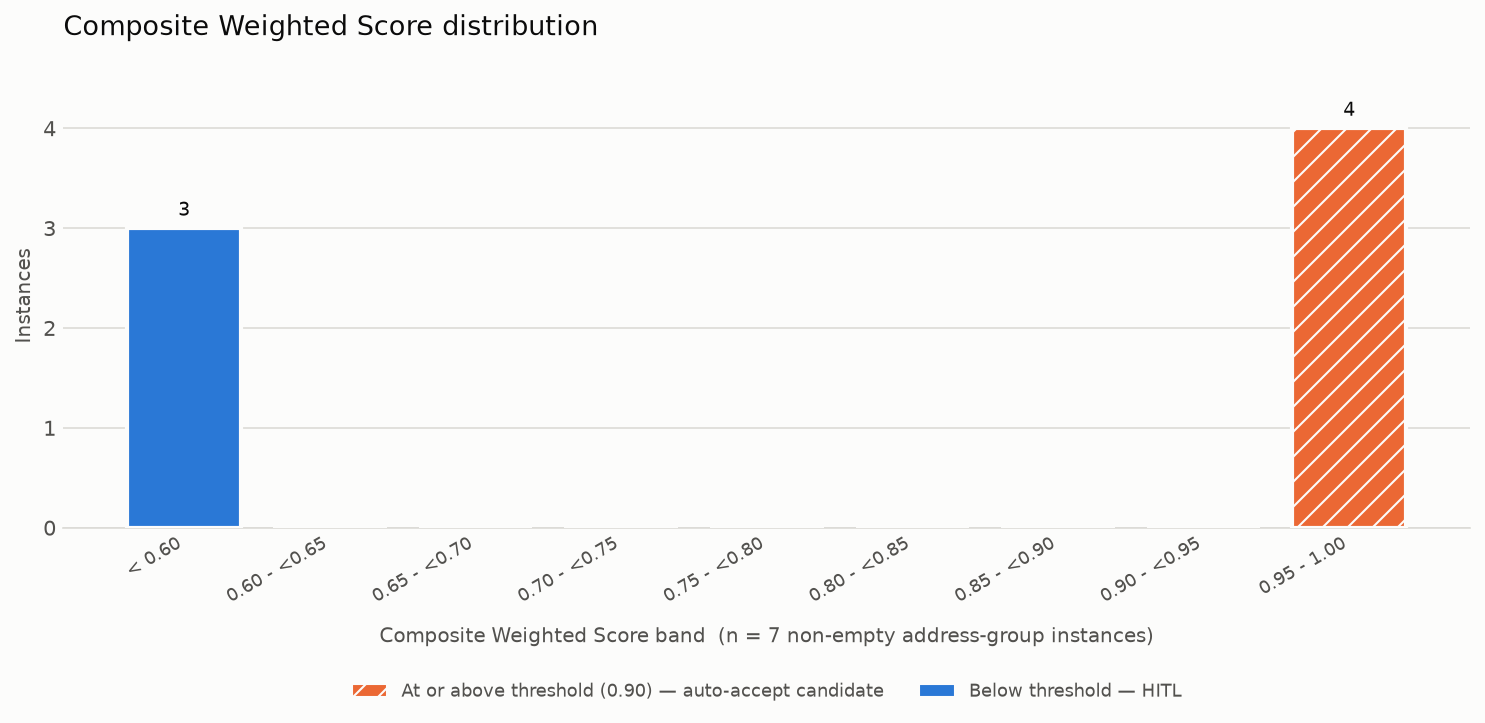

In [19]:
from IPython.display import Image

histogram_path = reporting.render_score_histogram(
    distribution,
    config.path(config.reporting.charts_dir) / config.reporting.histogram_filename,
    threshold=report_threshold,
    total_non_empty=non_empty,
)
display(Image(filename=str(histogram_path)))

### C — Scenario distribution

In [20]:
scenarios = reporting.build_scenario_distribution(result.instances)
display(scenarios)

print("\nReference-validation outcomes (audit-only, not CSV columns):")
for status, count in sorted(
    result.metrics["outcomes"]["reference_status_counts"].items()
):
    print(f"  {status:26} : {count}")

,scenario,observation_count,percent_of_non_empty
0,both_explicit,4,57.14
1,no_defensible_prediction,1,14.29
2,town_explicit_country_ambiguous,1,14.29
3,town_explicit_country_inferred,1,14.29



Reference-validation outcomes (audit-only, not CSV columns):
  consistent                 : 5
  multi_country_escalated    : 1
  no_town_predicted          : 1


### D — HITL threshold sensitivity

A score at or above the threshold is an auto-accept **candidate** — candidate, not accepted, because
unresolved country ambiguity, an extraction failure, and a model/reference conflict force review
whatever the number says. Those forced cases are broken out so the override is visible.

In [21]:
sensitivity = reporting.build_threshold_sensitivity(
    result.instances, config.reporting.sensitivity_thresholds
)
display(sensitivity)

,threshold,auto_accept_candidate_count,auto_accept_candidate_percent,hitl_count,hitl_percent,ambiguous_forced_hitl_count,error_forced_hitl_count
0,0.80,4,57.14,3,42.86,1,0
1,0.85,4,57.14,3,42.86,1,0
2,0.90,4,57.14,3,42.86,1,0
3,0.95,4,57.14,3,42.86,1,0


### E — Provisional routing recommendation

> **This is a provisional routing policy, not calibrated accuracy.**

`config.reporting.recommended_threshold` (currently **0.90**) is a conservative Phase 1 starting
point, and it is configuration — no reporting logic hard-codes it. The reasoning:

- the Composite Weighted Score already penalizes inferred values, so an inferred country cannot reach
  0.90 at all: the best `town_explicit_country_inferred` case is `(p_t x 0.75) x (p_c x 0.50)`, which
  caps at **0.375** even with perfect model confidence;
- any unresolved country ambiguity scores exactly **0.0** and is mandatory HITL regardless;
- so in practice 0.90 admits only `both_explicit`, where it requires roughly **0.95 on both**
  confidences if the two are similar (`0.95 x 0.95 = 0.9025`).

That makes 0.90 a *shape* decision — "auto-accept only when both Town and Country are explicitly
present in the address text and the model is highly confident" — rather than a tuned number.

**The final enterprise threshold must come from labeled validation data.** Once labels exist, extend
the sensitivity table with:

- precision of the auto-accepted population
- error rate of the auto-accepted population
- recall / coverage
- HITL volume at each threshold

and adopt the governance criterion: **choose the lowest threshold that still satisfies the
business-approved minimum precision** — optimize for precision at an accepted review cost, not for
throughput.

In [22]:
recommended = sensitivity[sensitivity["threshold"] == report_threshold]
current = config.scoring.hitl_threshold

print(f"configured hitl_threshold (scoring)      : {current}")
print(f"provisional recommendation (reporting)   : {report_threshold}")
print()
if not recommended.empty:
    row = recommended.iloc[0]
    print(f"At the recommended {report_threshold:.2f} threshold:")
    print(f"  auto-accept candidates : {int(row['auto_accept_candidate_count']):>4}  "
          f"({row['auto_accept_candidate_percent']:.1f}% of non-empty instances)")
    print(f"  routed to HITL         : {int(row['hitl_count']):>4}  "
          f"({row['hitl_percent']:.1f}%)")
    print(f"    forced by ambiguity  : {int(row['ambiguous_forced_hitl_count']):>4}")
    print(f"    forced by errors     : {int(row['error_forced_hitl_count']):>4}")

print("\nCeiling check — the highest composite score any inferred-country scenario can reach:")
for scenario in ("both_explicit", "town_explicit_country_inferred",
                 "country_explicit_town_inferred", "neither_explicit_both_inferred"):
    weights = config.scoring.weights_for(scenario)
    ceiling = weights.town_weight * weights.country_weight   # both confidences = 1.0
    verdict = "can clear" if ceiling >= report_threshold else "CANNOT clear"
    print(f"  {scenario:32} max {ceiling:.4f}  -> {verdict} {report_threshold:.2f}")

configured hitl_threshold (scoring)      : 0.8
provisional recommendation (reporting)   : 0.9

At the recommended 0.90 threshold:
  auto-accept candidates :    4  (57.1% of non-empty instances)
  routed to HITL         :    3  (42.9%)
    forced by ambiguity  :    1
    forced by errors     :    0

Ceiling check — the highest composite score any inferred-country scenario can reach:
  both_explicit                    max 1.0000  -> can clear 0.90
  town_explicit_country_inferred   max 0.3750  -> CANNOT clear 0.90
  country_explicit_town_inferred   max 0.5000  -> CANNOT clear 0.90
  neither_explicit_both_inferred   max 0.0400  -> CANNOT clear 0.90


### F — Write the report artifacts

In [23]:
report = reporting.write_reports(
    result.metrics, result.instances, config, threshold=report_threshold
)

for name, path in sorted(report.paths.items()):
    print(f"{name:22} -> {path}")

print("\nexecutive_summary.json:")
print(json.dumps(report.executive_summary, indent=2, default=str))

INFO    swift_address.reporting: wrote score histogram to /home/user/swift_tc/outputs/charts/composite_score_histogram.png


executive_summary      -> /home/user/swift_tc/outputs/reports/executive_summary.json
histogram              -> /home/user/swift_tc/outputs/charts/composite_score_histogram.png
scenario_distribution  -> /home/user/swift_tc/outputs/reports/scenario_distribution.csv
score_distribution     -> /home/user/swift_tc/outputs/reports/score_distribution.csv
threshold_sensitivity  -> /home/user/swift_tc/outputs/reports/threshold_sensitivity.csv

executive_summary.json:
{
  "run_timestamp": "2026-08-15T15:47:00+00:00",
  "mode": "dry_run",
  "model": "mock-dry-run",
  "prompt_version": "v2-composite-weighted",
  "reference_data_version": "iso3166-2026-08",
  "town_country_reference_version": "container-standin-2026-08-15",
  "town_country_approved_for_production": false,
  "hitl_threshold": 0.9,
  "records": 8,
  "address_group_instances": 128,
  "empty_instances_skipped": 121,
  "non_empty_address_instances": 7,
  "unique_addresses": 7,
  "backend_calls": 7,
  "auto_accept_candidates": 4,
  "auto_

In [24]:
# The executive artifacts are aggregate-only: safe to circulate, unlike the
# output CSV and the cache, which carry raw address data.
summary_text = json.dumps(
    [v for v in report.executive_summary.values() if isinstance(v, str)]
).upper()
leaked = [
    fragment for fragment in ("LINCOLN", "BOSTON", "GREENWICH", "ACCRA", "AUCKLAND",
                              "JIRON", "AERONAUTICA", "TAIPEI", "02111")
    if fragment in summary_text
]
assert not leaked, f"raw address fragments leaked into the summary: {leaked}"

assert len(distribution) == len(config.reporting.score_band_edges) + 1
assert distribution["observation_count"].sum() == non_empty
assert set(sensitivity["threshold"]) == set(config.reporting.sensitivity_thresholds)

print("Executive report checks passed.")
print(f"  score bands            : {len(distribution)}")
print(f"  histogram denominator  : {non_empty} non-empty instances")
print(f"  empty instances excluded: {result.metrics['pass1']['empty_instances_skipped']}")
print("  no raw address in executive_summary.json")

Executive report checks passed.
  score bands            : 9
  histogram denominator  : 7 non-empty instances
  empty instances excluded: 121
  no raw address in executive_summary.json
